# Lab 5a: Convolutional neural nets
In this lab we consider the [CIFAR dataset](https://www.openml.org/d/40926), but model it using convolutional neural networks instead of linear models.
There is no separate tutorial, but you can find lots of examples in the lecture notebook on convolutional neural networks. If you are very confident, you can also try to solve these exercises using PyTorch instead of TensorFlow.

Tip: You can run these exercises faster on a GPU (but they will also run fine on a CPU). If you do not have a GPU locally, you can upload this notebook to Google Colab. You can enable GPU support at “runtime” -> “change runtime type”.

In [1]:
# Auto-setup when running on Google Colab
if 'google.colab' in str(get_ipython()):
    !pip install openml

# General imports
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openml as oml

In [2]:
# Download CIFAR data. Takes a while the first time.
# This version returns 3x32x32 resolution images. 
# If you feel like it, repeat the exercises with the 96x96x3 resolution version by using ID 41103 
cifar = oml.datasets.get_dataset(40926) 
X, y, _, _ = cifar.get_data(target=cifar.default_target_attribute, dataset_format='array'); 
cifar_classes = {0: "airplane", 1: "automobile", 2: "bird", 3: "cat", 4: "deer",
                 5: "dog", 6: "frog", 7: "horse", 8: "ship", 9: "truck"}

/var/folders/76/dl3rv17s7xz76wgx74llyccm0000gn/T/ipykernel_39277/3346526928.py:5: FutureWarning: Support for `dataset_format='array'` will be removed in 0.15,start using `dataset_format='dataframe' to ensure your code will continue to work. You can use the dataframe's `to_numpy` function to continue using numpy arrays.
  X, y, _, _ = cifar.get_data(target=cifar.default_target_attribute, dataset_format='array');


In [3]:
# The dataset (40926) is in a weird 3x32x32 format, we need to reshape and transpose
Xr = X.reshape((len(X),3,32,32)).transpose(0,2,3,1)

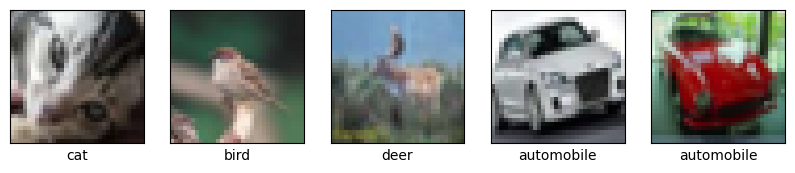

In [4]:
# Take some random examples, reshape to a 32x32 image and plot
from random import randint
fig, axes = plt.subplots(1, 5,  figsize=(10, 5))
for i in range(5):
    n = randint(0,len(Xr))
    # The data is stored in a 3x32x32 format, so we need to transpose it
    axes[i].imshow(Xr[n]/255)
    axes[i].set_xlabel((cifar_classes[int(y[n])]))
    axes[i].set_xticks(()), axes[i].set_yticks(())
plt.show();

## Exercise 1: A simple model
* Split the data into 80% training and 20% validation sets
* Normalize the data to [0,1]
* Build a ConvNet with 3 convolutional layers interspersed with MaxPooling layers, and one dense layer.
    * Use at least 32 3x3 filters in the first layer and ReLU activation.
    * Otherwise, make rational design choices or experiment a bit to see what works.
* You should at least get 60% accuracy.
* For training, you can try batch sizes of 64, and 20-50 epochs, but feel free to explore this as well
* Plot and interpret the learning curves. Is the model overfitting? How could you improve it further?

In [5]:
# import the libraries for PyTorch
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchmetrics
import tqdm

In [6]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [7]:
# normalise the data
X_normalised = Xr / 255.0

# Split the data into a training and test set
X_train, X_test, y_train, y_test = train_test_split(X_normalised, y, test_size=0.2, stratify=y, random_state=0)

# Convert the data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create a Dataset
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

In [8]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.flatten = nn.Flatten()
        self.dense1 = nn.Linear(64*2*2, 64)
        self.dense2 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = self.pool3(x)
        x = self.flatten(x)
        x = F.relu(self.dense1(x))
        x = self.dense2(x)
        return x

In [9]:
def train_model(model, train_dataset, val_dataset, epochs=20, batch_size=64, learning_rate=0.001):
    """
    model: the model to train
    train_dataset: the training data and labels
    test_dataset: the test data and labels
    epochs: the number of epochs to train for
    batch_size: the batch size for minibatch SGD
    learning_rate: the learning rate for the optimizer
    """
    
    train_loss = []
    val_loss = []
    train_accuracy = []
    val_accuracy = []

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.01)
    accuracy_metric = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model.to(device)

    for epoch in tqdm.tqdm(range(epochs)):
        model.train()

        running_loss, correct, total = 0.0, 0, 0

        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            correct += accuracy_metric(y_pred, y_batch).item() * y_batch.size(0)
            total += len(y_batch)
        
        train_loss.append(running_loss / len(train_loader))
        train_accuracy.append(correct / total)

        model.eval()
        running_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                y_pred = model(x_batch)
                loss = criterion(y_pred, y_batch)

                running_loss += loss.item()
                correct += accuracy_metric(y_pred, y_batch).item() * y_batch.size(0)
                total += len(y_batch)
            
            val_loss.append(running_loss / len(val_loader))
            val_accuracy.append(correct / total)
        
        # print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss[-1]:.4f} - Train Accuracy: {train_accuracy[-1]:.4f} - Val Loss: {val_loss[-1]:.4f} - Val Accuracy: {val_accuracy[-1]:.4f}")
    
    return train_loss, val_loss, train_accuracy, val_accuracy

In [10]:
def plot_curve(history):
    """
    Plots the learning curves for accuracy and loss.

    history: Dictionary containing 'accuracy', 'val_accuracy', 'loss', 'val_loss' per epoch.
    """
    epochs = range(1, len(history["accuracy"]) + 1)

    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["accuracy"], label="Train Accuracy")
    plt.plot(epochs, history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()

    plt.show()

In [11]:
model = ConvNet()

train_loss, val_loss, train_accuracy, val_accuracy = train_model(model, train_dataset, test_dataset, epochs=20, batch_size=64, learning_rate=0.001)

100%|██████████| 20/20 [00:48<00:00,  2.44s/it]


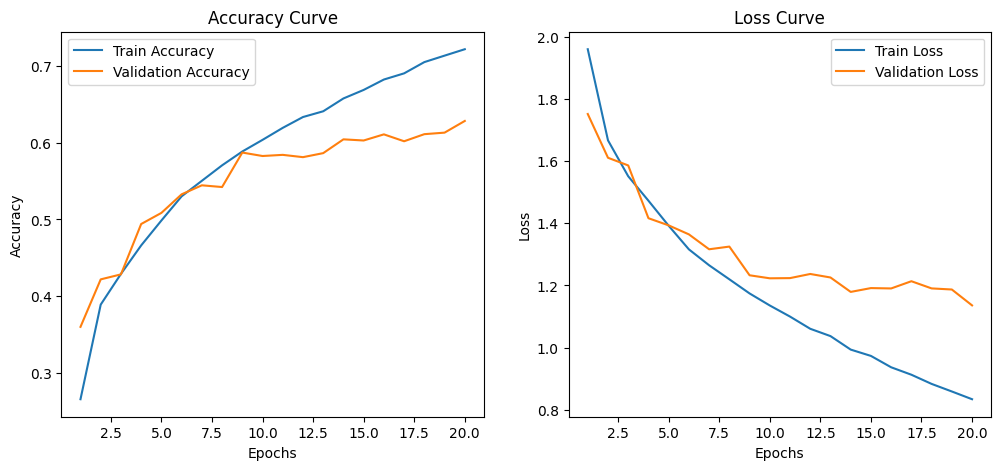

In [12]:
history = {
    "accuracy": train_accuracy,
    "val_accuracy": val_accuracy,
    "loss": train_loss,
    "val_loss": val_loss
}

plot_curve(history)

In [13]:
# report the final test accuracy
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor.to(device))
    test_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)(y_pred, y_test_tensor.to(device))
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.6285


Interpretation:
* The model is slightly overfitting
* Are able to achieve 60% accuracy

## Exercise 2: VGG-like model
* Implement a simplified VGG model by building 3 'blocks' of 2 convolutional layers each
* Do MaxPooling after each block
* The first block should use at least 32 filters, later blocks should use more
* You can use 3x3 filters
* Use zero-padding to be able to build a deeper model (see the `padding` attribute)
* Use a dense layer with at least 128 hidden nodes.
* You can use ReLU activations everywhere (where it makes sense)
* Plot and interpret the learning curves


In [14]:
class VGGBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(VGGBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),  # Padding to keep spatial dimensions
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        return self.block(x)
    

class SimplifiedVGG(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(SimplifiedVGG, self).__init__()

        self.block1 = VGGBlock(in_channels, 32)
        self.block2 = VGGBlock(32, 64)
        self.block3 = VGGBlock(64, 128)

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(128 * 4 * 4, num_classes)  # Adjust input size based on your data

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

In [15]:
model = SimplifiedVGG(3, 10)

train_loss, val_loss, train_accuracy, val_accuracy = train_model(model, train_dataset, test_dataset, epochs=20, batch_size=64, learning_rate=0.001)

100%|██████████| 20/20 [01:15<00:00,  3.78s/it]


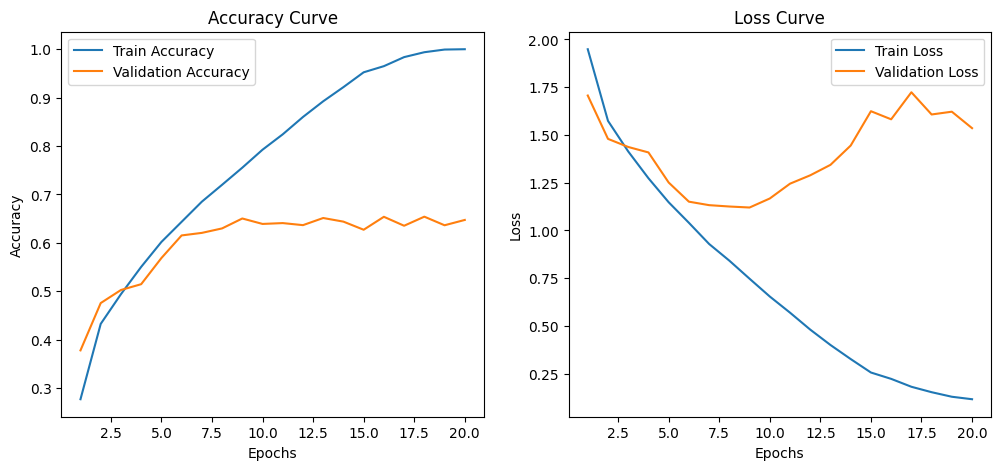

In [16]:
history = {
    "accuracy": train_accuracy,
    "val_accuracy": val_accuracy,
    "loss": train_loss,
    "val_loss": val_loss
}

plot_curve(history)

Interpetation:
* Achieves 60% accuracy as well
* Highly overfitting after around 6 epochs

## Exercise 3: Regularization
* Explore different ways to regularize your VGG-like model
  * Try adding some dropout after every MaxPooling and Dense layer.
    * What are good Dropout rates? Try a fixed Dropout rate, or increase the rates in the deeper layers.
  * Try batch normalization together with Dropout
    * Think about where batch normalization would make sense 
* Plot and interpret the learning curves


In [17]:
class VGGBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(VGGBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),  # Padding to keep spatial dimensions
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.50)
        )

    def forward(self, x):
        return self.block(x)


class RegularisedSimplifiedVGG(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(RegularisedSimplifiedVGG, self).__init__()

        self.block1 = VGGBlock(in_channels, 32)
        self.block2 = VGGBlock(32, 64)
        self.block3 = VGGBlock(64, 128)

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(128 * 4 * 4, num_classes)  # Adjust input size based on your data

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

In [ ]:
model = RegularisedSimplifiedVGG(3, 10)

train_loss, val_loss, train_accuracy, val_accuracy = train_model(model, train_dataset, test_dataset, epochs=50, batch_size=64, learning_rate=0.001)

100%|██████████| 100/100 [07:17<00:00,  4.37s/it]


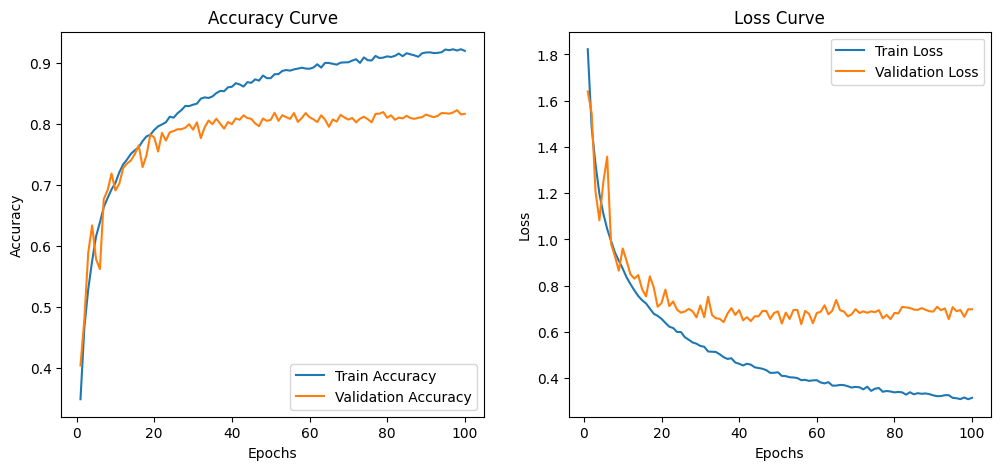

In [19]:
history = {
    "accuracy": train_accuracy,
    "val_accuracy": val_accuracy,
    "loss": train_loss,
    "val_loss": val_loss
}
plot_curve(history)

In [20]:
# report the final test accuracy
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor.to(device))
    test_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)(y_pred, y_test_tensor.to(device))
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.8160


Interpretation:
* Higher dropout works very well (.5 better than .2)
* Including dropout after the dense layer is not effective (maybe applied wrongly)
* Adding batch normalization after the convolutional layers is effective, reaching 81% accuracy
* Starts overfitting after around 30-40 epochs

## Exercise 4: Data Augmentation
* Perform image augmentation (rotation, shift, shear, zoom, flip,...). You can use the ImageDataGenerator for this.
* What is the effect? What is the effect with and without Dropout?
* Plot and interpret the learning curves


In [30]:
# write the images to a folder
import os
from PIL import Image

def save_images(images, folder):
    if not os.path.exists(folder):
        os.makedirs(folder)
    else:
        for file in os.listdir(folder):
            os.remove(f"{folder}/{file}")
    for i, image in enumerate(images):
        img = Image.fromarray((image * 255).astype(np.uint8))
        img.save(f"{folder}/{i}.png")

save_images(Xr, "cifar10_images")

In [34]:
import torchvision.datasets as datasets

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, shear=10, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

## Exercise 5: Interpret the misclassifications
Chances are that even your best model is not yet perfect. It is important to understand what kind of errors it still makes.
* Run the test images through the network and detect all misclassified ones
* Interpret some of the misclassifications. Are these misclassifications to be expected? 
* Compute the confusion matrix. Which classes are often confused?

In [37]:
# report the final test accuracy
model.eval()

all_predictions = []

misclassified_images = []
misclassified_labels = []
misclassified_predictions = []

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        y_pred = model(x_batch)
        predictions = torch.argmax(y_pred, dim=1)
        all_predictions.extend(predictions.cpu().numpy())
        misclassified_images.extend(x_batch[predictions != y_batch].cpu().numpy())
        misclassified_labels.extend(y_batch[predictions != y_batch].cpu().numpy())
        misclassified_predictions.extend(predictions[predictions != y_batch].cpu().numpy())

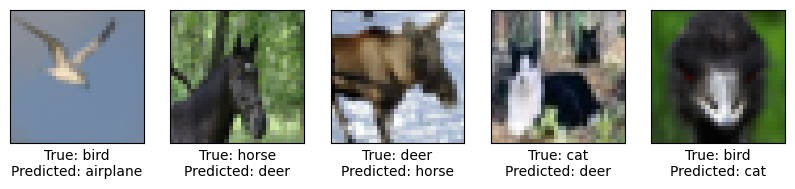

In [39]:
# plot 5 random misclassified images
fig, axes = plt.subplots(1, 5, figsize=(10, 5))

for i in range(5):
    n = randint(0, len(misclassified_images))
    axes[i].imshow(misclassified_images[n].transpose(1, 2, 0))
    axes[i].set_xlabel(f"True: {cifar_classes[misclassified_labels[n]]}\nPredicted: {cifar_classes[misclassified_predictions[n]]}")
    axes[i].set_xticks(()), axes[i].set_yticks(())
plt.show()

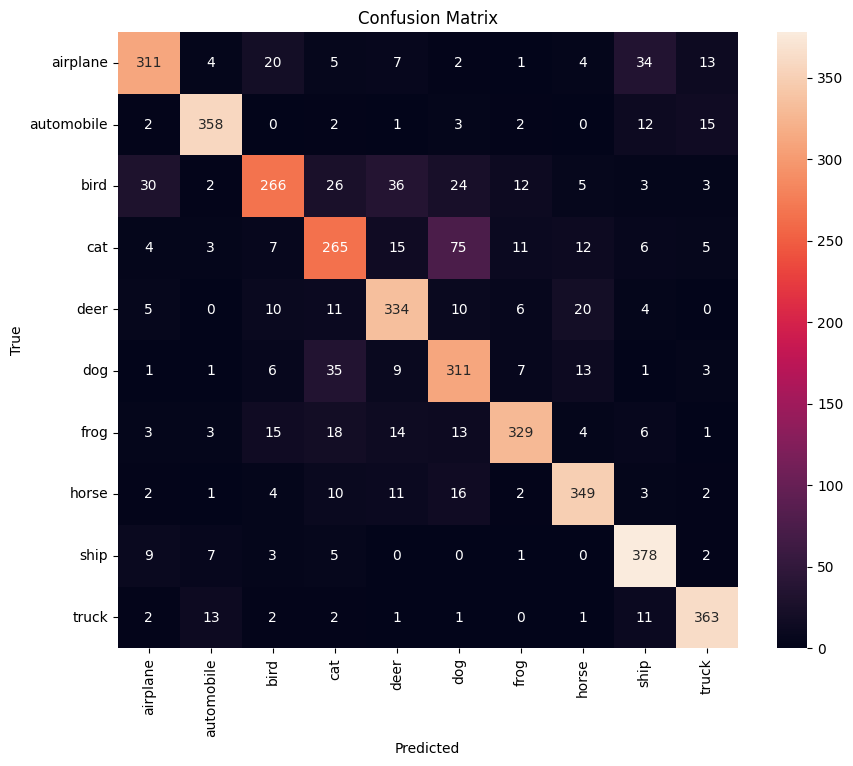

In [38]:
# plot the confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, all_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=cifar_classes.values(), yticklabels=cifar_classes.values())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## Exercise 6: Interpret the model
Retrain your best model on all the data. Next, retrieve and visualize the activations (feature maps) for every filter for every convolutional layer, or at least for a few filters for every layer. Tip: see the course notebooks for examples on how to do this. 

Interpret the results. Is your model indeed learning something useful?

## Optional: Take it a step further
* Repeat the exercises, but now use a [higher-resolution version of the CIFAR dataset](https://www.openml.org/d/40926) (with OpenML ID 41103), or another [version with 100 classes](https://www.openml.org/d/41983) (with OpenML ID 41983). Good luck!
